In [16]:
file_path = "/home/kbas/scratch/String340MC_pone_offline_version3_plus/Muon_PMT_Response/muon_cls_000.i3.gz"

In [20]:
from icecube import dataio, simclasses
from icecube import LeptonInjector

i3file = dataio.I3File(file_path)

frame = i3file.pop_daq()


print(frame)

[ I3Frame  (DAQ):
  'Accepted_PulseMap_102_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (1284)
  'Accepted_PulseMap_160_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (3711)
  'Accepted_PulseMap_340String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (3711)
  'EventProperties' [DAQ] ==> LeptonInjector::BasicEventProperties (140)
  'I3EventHeader' [DAQ] ==> I3EventHeader (99)
  'I3MCTree' [DAQ] ==> TreeBase::Tree<I3Particle, I3ParticleID, i3hash<I3ParticleID> > (422)
  'I3MCTree_RNGState' [DAQ] ==> I3GSLRandomServiceState (87)
  'I3MCTree_postprop' [DAQ] ==> TreeBase::Tree<I3Particle, I3ParticleID, i3hash<I3ParticleID> > (2778)
  'I3Photons' [DAQ] ==> I3Map<ModuleKey, I3Vector<I3CompressedPhoton> > (115519)
  'MMCTrackList' [DAQ] ==> I3Vector<I3MMCTrack> (304)
  'Noise_Dark_340_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (51453)
  'Noise_K40_340_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (163611)
  'PMT_Response_102_String' [DAQ] ==> I3Map<OMKey, vector<I3RecoPulse> > (62950)
  

In [24]:
print(frame["trigger_time_noisy_102_string"])
print(frame["trigger_time_noisy_160_string"])
print(frame["trigger_time_noisy_340_string"])



print(frame["trigger_time_nonoise_102_string"])
print(frame["trigger_time_nonoise_160_string"])
print(frame["trigger_time_nonoise_340_string"])
    

    


I3Double(1287)
I3Double(299)
I3Double(299)
I3Double(1287)
I3Double(299)
I3Double(299)


# Triggered by all

In [17]:
from icecube import dataio, simclasses
from icecube import LeptonInjector

i3file = dataio.I3File(file_path)

first_frame = None
first_frame_index = None

def is_triggered(value):
    if hasattr(value, "value"):
        value = value.value
    return bool(value)

frame_index = 0
while i3file.more():
    frame = i3file.pop_frame()
    if "triggered_340_string" in frame and is_triggered(frame["triggered_340_string"]):
        first_frame = frame
        first_frame_index = frame_index
        break
    frame_index += 1

i3file.close()

if first_frame is None:
    raise RuntimeError("No frame found with triggered_340_string == 1")

print(f"Found triggered_340_string == 1 at frame index {first_frame_index}")
first_frame

RuntimeError: No frame found with triggered_340_string == 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt



def value_as_float(value):
    if hasattr(value, "value"):
        value = value.value
    return float(value)


def pulse_charge_like(pulse):
    if hasattr(pulse, "charge"):
        return float(pulse.charge)
    if hasattr(pulse, "npe"):
        return float(pulse.npe)
    return 1.0


def pulse_times_and_charges(frame, key):
    if key not in frame:
        raise KeyError(f"Missing frame key: {key}")

    times = []
    charges = []
    pmts = []
    pulse_map = frame[key]

    for omkey in pulse_map.keys():
        pmt_label = f"{omkey.string}-{omkey.om}-{omkey.pmt}"
        for pulse in pulse_map[omkey]:
            times.append(float(pulse.time))
            charges.append(pulse_charge_like(pulse))
            pmts.append(pmt_label)

    return np.asarray(times), np.asarray(charges), pmts


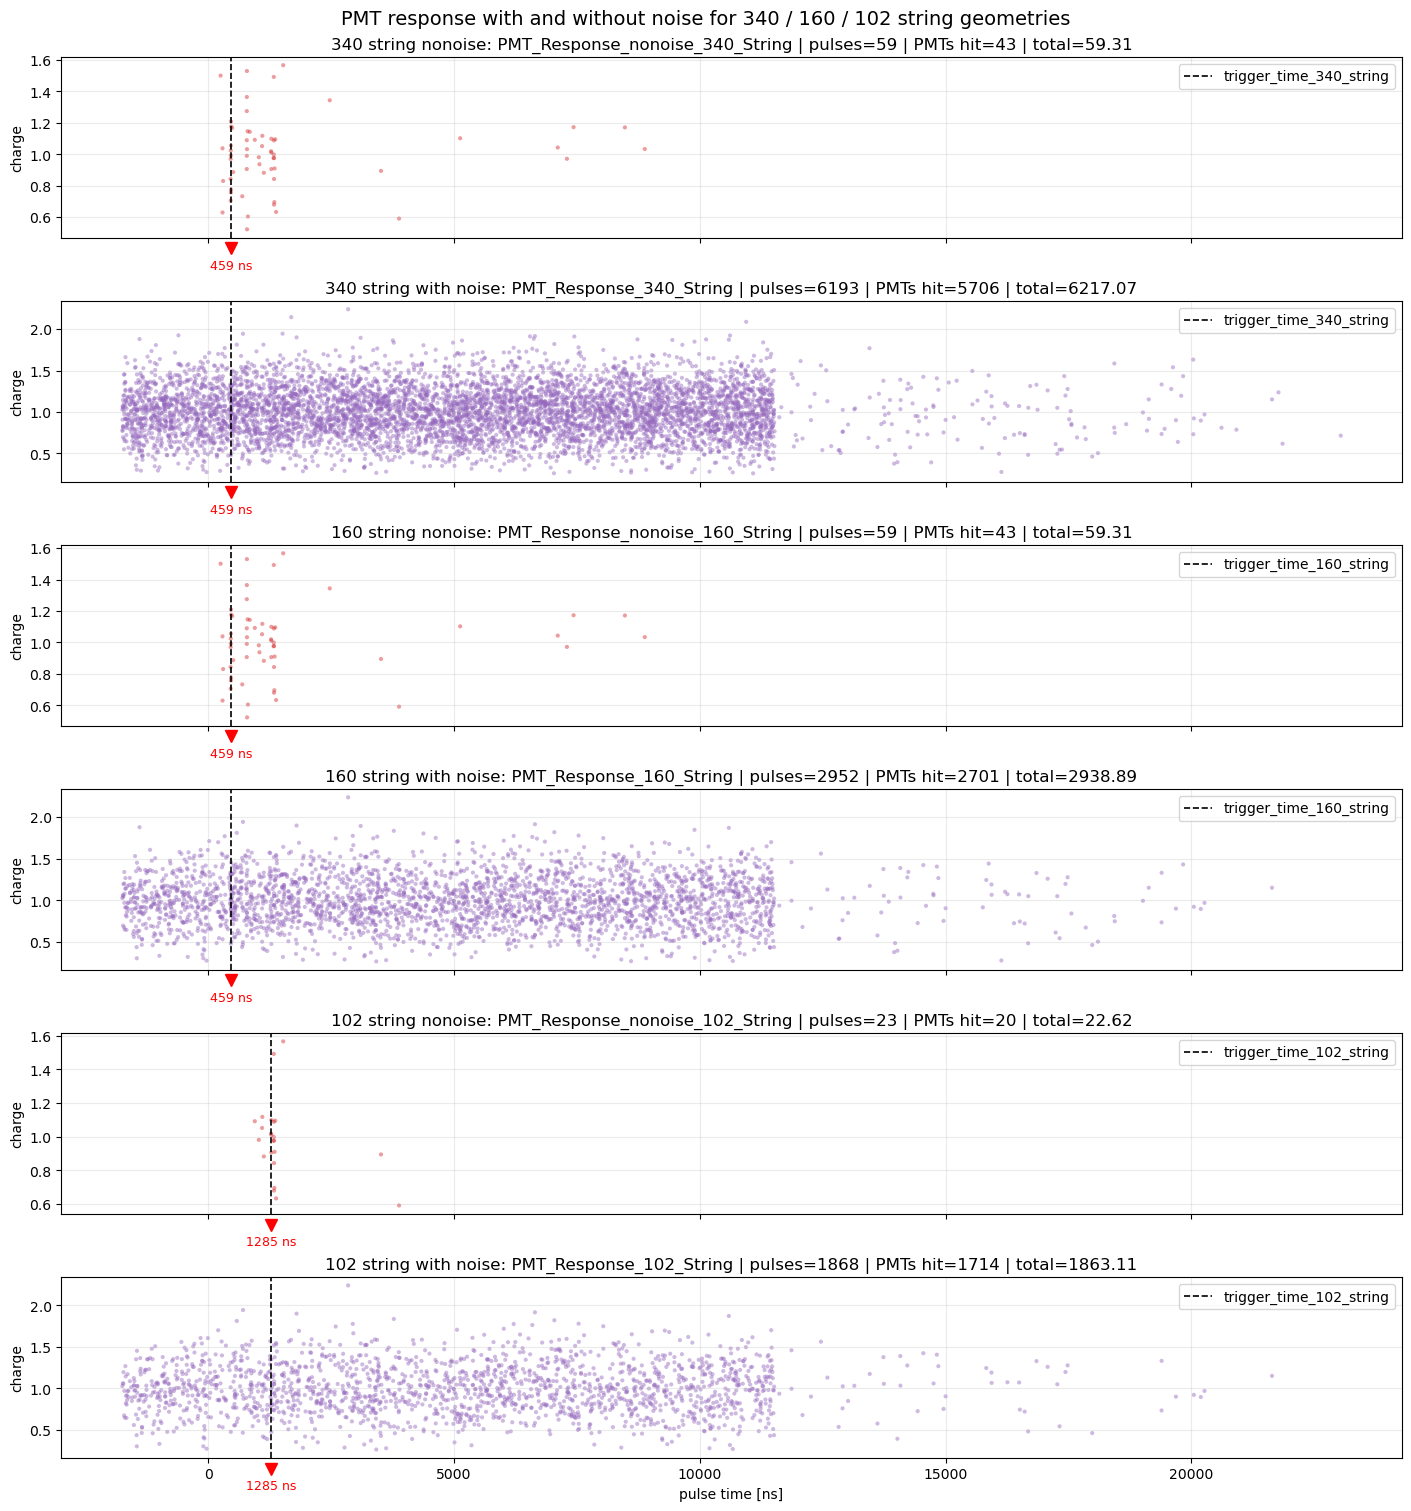

In [4]:

plot_keys = [
    ("340 string nonoise", "PMT_Response_nonoise_340_String", "trigger_time_340_string", "tab:red", "charge"),
    ("340 string with noise", "PMT_Response_340_String", "trigger_time_340_string", "tab:purple", "charge"),
    ("160 string nonoise", "PMT_Response_nonoise_160_String", "trigger_time_160_string", "tab:red", "charge"),
    ("160 string with noise", "PMT_Response_160_String", "trigger_time_160_string", "tab:purple", "charge"),
    ("102 string nonoise", "PMT_Response_nonoise_102_String", "trigger_time_102_string", "tab:red", "charge"),
    ("102 string with noise", "PMT_Response_102_String", "trigger_time_102_string", "tab:purple", "charge"),
]

series = []
for label, map_key, trigger_key, color, ylabel in plot_keys:
    times, charges, pmts = pulse_times_and_charges(first_frame, map_key)
    trigger_time = value_as_float(first_frame[trigger_key]) if trigger_key and trigger_key in first_frame else np.nan
    series.append((label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel))

all_times = np.concatenate([times for _, _, _, _, times, _, _, _, _ in series if len(times)])
if len(all_times) == 0:
    raise RuntimeError("No pulses found in the selected maps")

fig, axes = plt.subplots(len(plot_keys), 1, figsize=(14, 15), sharex=True, constrained_layout=True)

for ax, (label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel) in zip(axes, series):
    ax.scatter(times, charges, s=9, alpha=0.45, color=color, edgecolors="none")

    if np.isfinite(trigger_time) and trigger_time >= 0:
        ax.axvline(
            trigger_time,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=trigger_key,
        )
        ax.plot(
            trigger_time,
            -0.06,
            marker="v",
            markersize=9,
            color="red",
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.text(
            trigger_time,
            -0.12,
            f"{trigger_time:.0f} ns",
            color="red",
            ha="center",
            va="top",
            fontsize=9,
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.legend(loc="upper right")

    ax.set_ylabel(ylabel)
    ax.set_title(
        f"{label}: {map_key} | pulses={len(times)} | PMTs hit={len(set(pmts))} | total={charges.sum():.2f}"
    )
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("pulse time [ns]")
fig.suptitle("PMT response with and without noise for 340 / 160 / 102 string geometries", fontsize=14)
plt.show()


# Triggered by 340. not triggered by the rest

In [5]:
from icecube import dataio, simclasses

def flag_as_bool(frame, key):
    if key not in frame:
        return False
    value = frame[key]
    if hasattr(value, "value"):
        value = value.value
    return bool(value)

only_340_frame = None
only_340_frame_index = None
daq_index = 0

i3file = dataio.I3File(file_path)
while i3file.more():
    frame = i3file.pop_frame()
    if "PMT_Response_nonoise_340_String" not in frame:
        continue

    triggered_340 = flag_as_bool(frame, "triggered_340_string")
    triggered_160 = flag_as_bool(frame, "triggered_160_string")
    triggered_102 = flag_as_bool(frame, "triggered_102_string")

    if triggered_340 and not triggered_160 and not triggered_102:
        only_340_frame = frame
        only_340_frame_index = daq_index
        break

    daq_index += 1

i3file.close()

if only_340_frame is None:
    raise RuntimeError("No frame found with 340 triggered and 160/102 not triggered")

print(f"Found example at DAQ-like frame index {only_340_frame_index}")
for key in [
    "triggered_340_string", "trigger_time_340_string",
    "triggered_160_string", "trigger_time_160_string",
    "triggered_102_string", "trigger_time_102_string",
]:
    print(f"{key}: {only_340_frame[key] if key in only_340_frame else 'MISSING'}")

Found example at DAQ-like frame index 6
triggered_340_string: I3Double(1)
trigger_time_340_string: I3Double(6115)
triggered_160_string: I3Double(0)
trigger_time_160_string: I3Double(-1)
triggered_102_string: I3Double(0)
trigger_time_102_string: I3Double(-1)


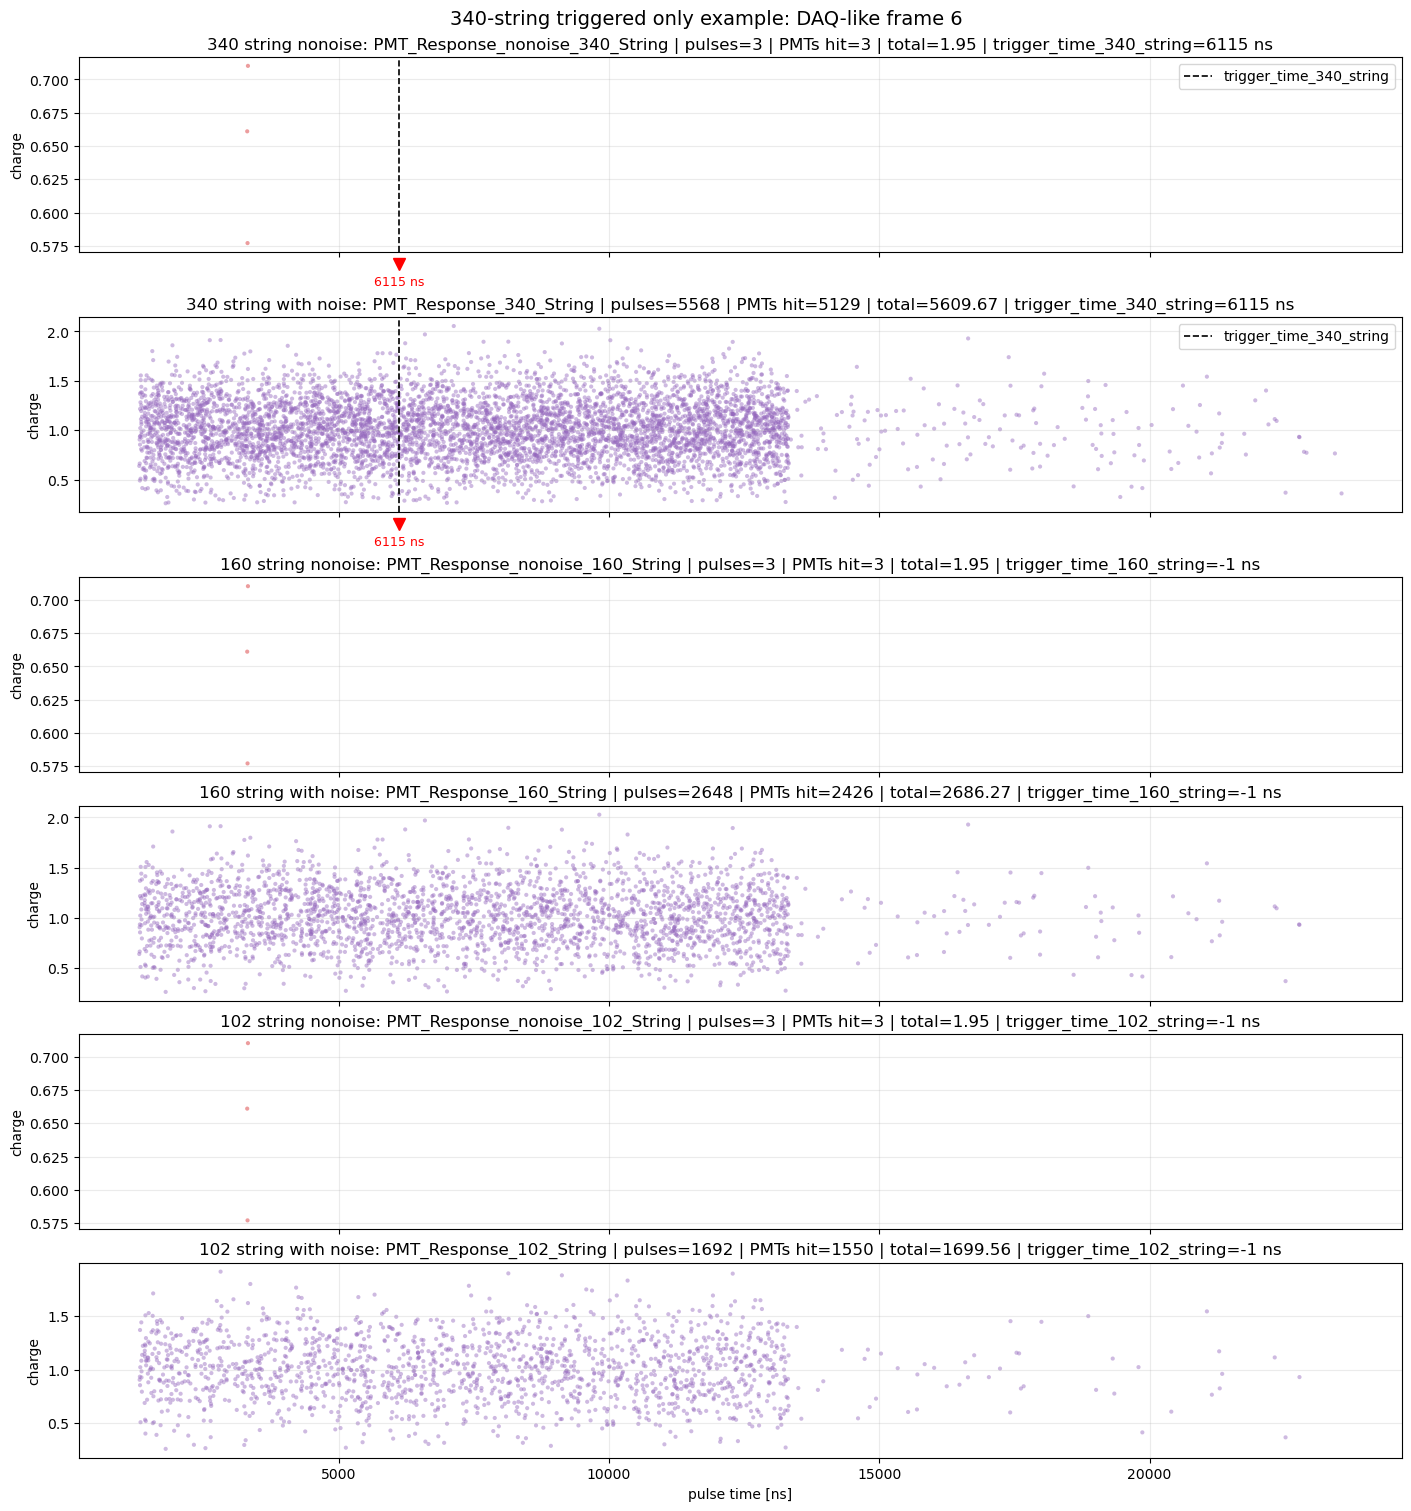

In [6]:
series = []
for label, map_key, trigger_key, color, ylabel in plot_keys:
    times, charges, pmts = pulse_times_and_charges(only_340_frame, map_key)
    trigger_time = value_as_float(only_340_frame[trigger_key]) if trigger_key and trigger_key in only_340_frame else np.nan
    series.append((label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel))

all_times = np.concatenate([times for _, _, _, _, times, _, _, _, _ in series if len(times)])
if len(all_times) == 0:
    raise RuntimeError("No pulses found in the selected maps")

fig, axes = plt.subplots(len(plot_keys), 1, figsize=(14, 15), sharex=True, constrained_layout=True)

for ax, (label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel) in zip(axes, series):
    ax.scatter(times, charges, s=9, alpha=0.45, color=color, edgecolors="none")

    if np.isfinite(trigger_time) and trigger_time >= 0:
        ax.axvline(
            trigger_time,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=trigger_key,
        )
        ax.plot(
            trigger_time,
            -0.06,
            marker="v",
            markersize=9,
            color="red",
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.text(
            trigger_time,
            -0.12,
            f"{trigger_time:.0f} ns",
            color="red",
            ha="center",
            va="top",
            fontsize=9,
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.legend(loc="upper right")

    trigger_label = ""
    if trigger_key:
        trigger_label = f" | {trigger_key}={trigger_time:.0f} ns"

    ax.set_ylabel(ylabel)
    ax.set_title(
        f"{label}: {map_key} | pulses={len(times)} | PMTs hit={len(set(pmts))} | total={charges.sum():.2f}{trigger_label}"
    )
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("pulse time [ns]")
fig.suptitle(
    f"340-string triggered only example: DAQ-like frame {only_340_frame_index}",
    fontsize=14,
)
plt.show()

# Triggered by 340 and 160. not triggered by 102

In [7]:
from icecube import dataio, simclasses

triggered_340_160_frame = None
triggered_340_160_frame_index = None
daq_index = 0

i3file = dataio.I3File(file_path)
while i3file.more():
    frame = i3file.pop_frame()
    if "PMT_Response_nonoise_340_String" not in frame:
        continue

    triggered_340 = flag_as_bool(frame, "triggered_340_string")
    triggered_160 = flag_as_bool(frame, "triggered_160_string")
    triggered_102 = flag_as_bool(frame, "triggered_102_string")

    if triggered_340 and triggered_160 and not triggered_102:
        triggered_340_160_frame = frame
        triggered_340_160_frame_index = daq_index
        break

    daq_index += 1

i3file.close()

if triggered_340_160_frame is None:
    raise RuntimeError("No frame found with 340/160 triggered and 102 not triggered")

print(f"Found example at DAQ-like frame index {triggered_340_160_frame_index}")
for key in [
    "triggered_340_string", "trigger_time_340_string",
    "triggered_160_string", "trigger_time_160_string",
    "triggered_102_string", "trigger_time_102_string",
]:
    print(f"{key}: {triggered_340_160_frame[key] if key in triggered_340_160_frame else 'MISSING'}")

Found example at DAQ-like frame index 35
triggered_340_string: I3Double(1)
trigger_time_340_string: I3Double(713)
triggered_160_string: I3Double(1)
trigger_time_160_string: I3Double(8074)
triggered_102_string: I3Double(0)
trigger_time_102_string: I3Double(-1)


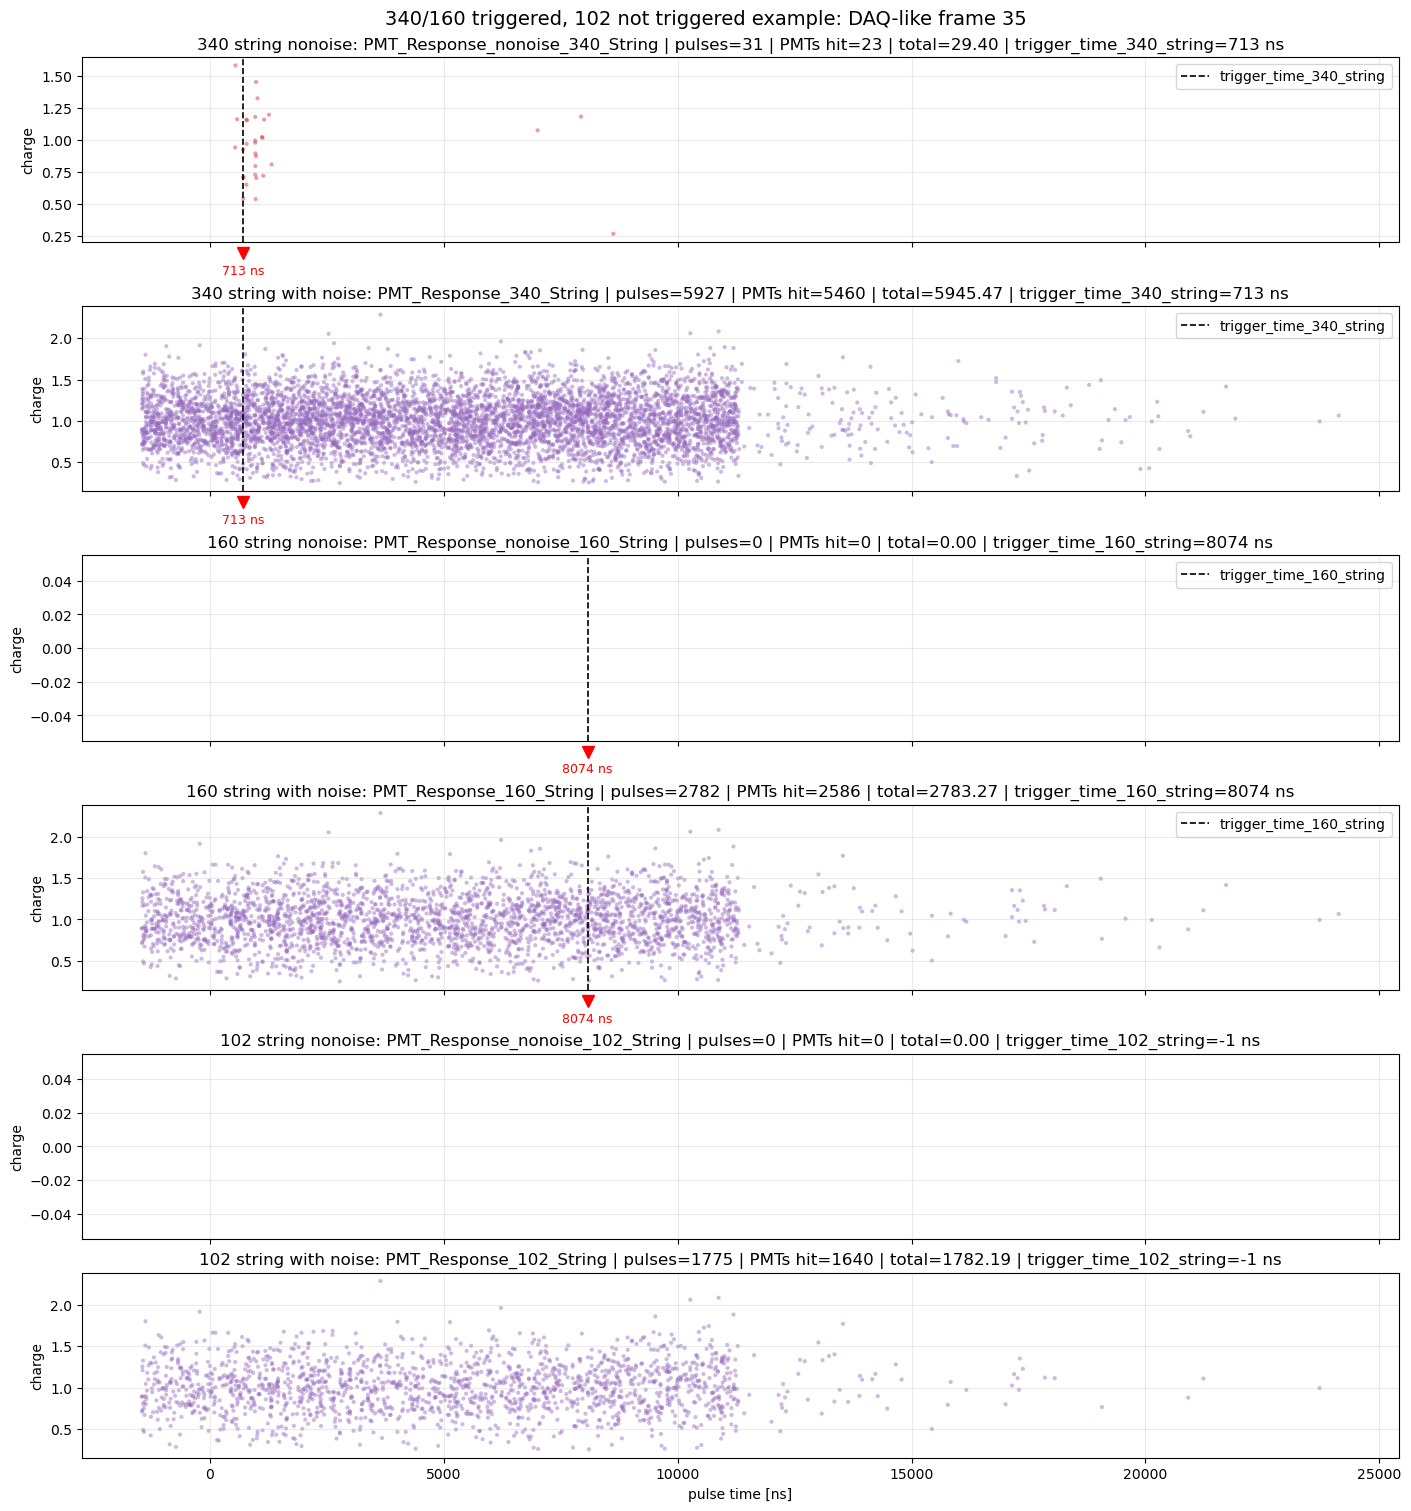

In [8]:
series = []
for label, map_key, trigger_key, color, ylabel in plot_keys:
    times, charges, pmts = pulse_times_and_charges(triggered_340_160_frame, map_key)
    trigger_time = value_as_float(triggered_340_160_frame[trigger_key]) if trigger_key and trigger_key in triggered_340_160_frame else np.nan
    series.append((label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel))

all_times = np.concatenate([times for _, _, _, _, times, _, _, _, _ in series if len(times)])
if len(all_times) == 0:
    raise RuntimeError("No pulses found in the selected maps")

fig, axes = plt.subplots(len(plot_keys), 1, figsize=(14, 15), sharex=True, constrained_layout=True)

for ax, (label, map_key, trigger_key, trigger_time, times, charges, pmts, color, ylabel) in zip(axes, series):
    ax.scatter(times, charges, s=9, alpha=0.45, color=color, edgecolors="none")

    if np.isfinite(trigger_time) and trigger_time >= 0:
        ax.axvline(
            trigger_time,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=trigger_key,
        )
        ax.plot(
            trigger_time,
            -0.06,
            marker="v",
            markersize=9,
            color="red",
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.text(
            trigger_time,
            -0.12,
            f"{trigger_time:.0f} ns",
            color="red",
            ha="center",
            va="top",
            fontsize=9,
            transform=ax.get_xaxis_transform(),
            clip_on=False,
        )
        ax.legend(loc="upper right")

    trigger_label = ""
    if trigger_key:
        trigger_label = f" | {trigger_key}={trigger_time:.0f} ns"

    ax.set_ylabel(ylabel)
    ax.set_title(
        f"{label}: {map_key} | pulses={len(times)} | PMTs hit={len(set(pmts))} | total={charges.sum():.2f}{trigger_label}"
    )
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("pulse time [ns]")
fig.suptitle(
    f"340/160 triggered, 102 not triggered example: DAQ-like frame {triggered_340_160_frame_index}",
    fontsize=14,
)
plt.show()